# 10 — PEST with IWFM, Part 2: Analyzing IES Results

After a PESTPP-IES run finishes you have a master directory full of
ensembles, phi tables, and residual files. `iwfm_io.pest` post-processes
them:

- **`load_ies_ensembles`** — lazy, cached access to everything IES wrote
- **`ies_stats` / `rei_stats` / `residual_stats`** — RMSE, bias, R²,
  NSE, KGE, phi at ensemble scale
- **`diagnose_ies`** — convergence, collapse, prior-data conflict,
  bound railing, bias, objective balance as machine-readable signals
- **derived observations** — the DWR-proven regularizers
- **`iwfm_io.plots.calibration`** — the figure set

CSV ensembles need nothing extra; `.jcb` binary ensembles need
`pip install iwfm-io[pest]` (pyemu).

So the notebook runs anywhere, it first **synthesizes** a small but
format-faithful IES master directory (20 realizations, 4 iterations, a
declining phi) — the generator doubles as documentation of the PESTPP
file formats. Point `load_ies_ensembles` at your own master directory
and every cell below works unchanged.

In [1]:
import os
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd

WORK = Path(tempfile.mkdtemp(prefix="iwfm_nb10_"))
MASTER = WORK / "master"
MASTER.mkdir()
CASE = "demo_ies"
rng = np.random.default_rng(11)

## Synthesize a PESTPP-IES output set

Three observation wells × 24 month-ends (`gwh` group) plus four budget
observations (`bud` group); six parameters. Simulated values start
biased and noisy and improve each iteration.

In [2]:
dates = pd.date_range("1998-01-31", periods=24, freq="ME")
wells = ["obs_a", "obs_b", "obs_c"]

from iwfm_io.pest import encode_obs_names

obs_names, truth = [], {}
for i, w in enumerate(wells):
    names = encode_obs_names("gwh", w, dates)
    obs_names += names.tolist()
    truth.update(dict(zip(
        names, 250 - 8 * i + 3 * np.sin(np.arange(24) * 2 * np.pi / 12))))
for j, b in enumerate(["dperc_sr01", "dperc_sr02", "pump_sr01", "pump_sr02"]):
    n = f"bud_{b}"
    obs_names.append(n)
    truth[n] = 1000.0 * (j + 1)
observed = pd.Series(truth)

pars = ["strk_upper", "strk_lower", "khall", "sy_mult", "rch_mult", "etaw"]
reals = [str(i) for i in range(20)] + ["base"]
n_iter = 4

In [3]:
# per-iteration ensembles: parameters narrow, simulations approach truth
par_center = np.log10([2.0, 0.5, 1.5, 0.9, 1.1, 1.0])
bias0 = rng.normal(0, 6, len(obs_names))          # initial systematic error

for it in range(n_iter):
    shrink = 0.45 ** it
    par = pd.DataFrame(
        10 ** (par_center + rng.normal(0, 0.35 * shrink, (len(reals), len(pars)))),
        index=pd.Index(reals, name="real_name"), columns=pars)
    par.loc["base"] = 10 ** par_center            # base = center values
    par.to_csv(MASTER / f"{CASE}.{it}.par.csv")

    sim = pd.DataFrame(
        observed.values + bias0 * shrink
        + rng.normal(0, 2.5 * shrink + 0.3, (len(reals), len(obs_names))),
        index=pd.Index(reals, name="real_name"), columns=obs_names)
    sim.to_csv(MASTER / f"{CASE}.{it}.obs.csv")

print("wrote", sorted(p.name for p in MASTER.glob("*.par.csv")))

wrote ['demo_ies.0.par.csv', 'demo_ies.1.par.csv', 'demo_ies.2.par.csv', 'demo_ies.3.par.csv']


In [4]:
# obs+noise: the observation ensemble IES actually fits (obs + noise draws)
noise = pd.DataFrame(
    observed.values + rng.normal(0, 0.8, (len(reals), len(obs_names))),
    index=pd.Index(reals, name="real_name"), columns=obs_names)
noise.loc["base"] = observed.values
noise.to_csv(MASTER / f"{CASE}.obs+noise.csv")

# phi tables (composite + actual + per-group), computed from the ensembles
groups = ["gwh" if n.startswith("gwh") else "bud" for n in obs_names]
weights = np.where([g == "gwh" for g in groups], 1.0, 0.02)

comp_rows, act_rows, grp_rows = [], [], []
for it in range(n_iter):
    sim = pd.read_csv(MASTER / f"{CASE}.{it}.obs.csv", index_col=0)
    res = (sim - observed.values) * weights
    phi = (res ** 2).sum(axis=1)
    comp_rows.append([it, len(reals), phi.mean(), phi.std(), phi.min(),
                      phi.max()] + phi.tolist())
    act_rows.append(comp_rows[-1])
    for r in reals:
        by_grp = (res.loc[r] ** 2).groupby(pd.Series(groups, index=obs_names)).sum()
        grp_rows.append([it, len(reals), r, r, by_grp["gwh"], by_grp["bud"]])

header = "iteration,total_runs,mean,standard_deviation,min,max," + \
    ",".join(reals) + ","
for kind, rows in [("composite", comp_rows), ("actual", act_rows)]:
    text = header + "\n" + "\n".join(
        ",".join(f"{v}" for v in row) + "," for row in rows)
    (MASTER / f"{CASE}.phi.{kind}.csv").write_text(text + "\n")

pd.DataFrame(grp_rows, columns=[
    "iteration", "total_runs", "obs_realization", "par_realization",
    "gwh", "bud"]).to_csv(MASTER / f"{CASE}.phi.group.csv", index=False)

In [5]:
# prior-data conflict + the base realization's residual (.rei) file
last = pd.read_csv(MASTER / f"{CASE}.{n_iter - 1}.obs.csv", index_col=0)
pdc = pd.DataFrame({
    "name": obs_names[:2],
    "obs_mean": observed.iloc[:2].values, "obs_std": [0.8, 0.8],
    "sim_mean": last[obs_names[:2]].mean().values,
    "sim_std": last[obs_names[:2]].std().values,
    "distance": [12.0, 9.5]})
pdc.to_csv(MASTER / f"{CASE}.pdc.csv", index=False)

rei_lines = [" MODEL OUTPUTS AT END OF OPTIMISATION ITERATION NO. 3:-",
             "", "",
             " Name  Group  Measured  Modelled  Residual  Weight"]
for n, g, w in zip(obs_names, groups, weights):
    mod = last.loc["base", n]
    rei_lines.append(f" {n} {g} {observed[n]:.4f} {mod:.4f} "
                     f"{observed[n] - mod:.4f} {w:.4f}")
(MASTER / f"{CASE}.{n_iter - 1}.base.rei").write_text("\r\n".join(rei_lines))
(MASTER / f"{CASE}.pst").write_text("pcf\n")
print("master directory complete:", len(list(MASTER.iterdir())), "files")

master directory complete: 15 files


## Load: `load_ies_ensembles`

Point it at the `.pst`, the directory, or the case prefix. Everything is
discovered, lazy, and cached. **Start with `describe()`** — it tells you
which iterations exist, which files were found, and the phi trajectory.

In [6]:
from iwfm_io.pest import load_ies_ensembles

r = load_ies_ensembles(MASTER / f"{CASE}.pst")
r.describe()

{'case': 'demo_ies',
 'directory': 'C:\\Users\\serca\\AppData\\Local\\Temp\\iwfm_nb10_ni8pcav6\\master',
 'iterations': [0, 1, 2, 3],
 'par_iterations': [0, 1, 2, 3],
 'obs_iterations': [0, 1, 2, 3],
 'phi_kinds': ['actual', 'composite'],
 'has_group_phi': True,
 'has_pdc': True,
 'has_obs_plus_noise': True,
 'rei_iterations': [3],
 'phi_mean_by_iteration': {0: 2426.62, 1: 509.81, 2: 116.49, 3: 36.4}}

In [7]:
# parameter / observation ensembles: default = last iteration
par = r.par()
print(f"par(): {par.shape} (last iteration)")
par.head(3)

par(): (21, 6) (last iteration)


,strk_upper,strk_lower,khall,sy_mult,rch_mult,etaw
real_name,,,,,,
0,2.166636,0.485214,1.730818,0.864696,1.092332,0.963932
1,1.967809,0.519119,1.484736,0.986221,1.139532,1.128656
2,2.018227,0.552360,1.646292,0.894106,1.332992,1.123293


In [8]:
# tidy phi, summary per iteration, and the best realization
print(r.phi_summary()[["total_runs", "mean", "min", "max"]])
print("\nbest realization (min phi, last iteration):", r.best_realization())

           total_runs         mean          min          max
iteration                                                   
0                  21  2426.623120  1871.271386  2976.561945
1                  21   509.814654   398.050258   624.444791
2                  21   116.487551    95.124236   161.215680
3                  21    36.398371    29.696674    43.699603

best realization (min phi, last iteration): 14


In [9]:
r.phi().head(4)

,iteration,real_name,phi
0,0,0,2628.773659
1,1,0,536.706124
2,2,0,117.375235
3,3,0,36.351201


In [10]:
# per-group phi and prior-data conflict
print(r.phi_groups().tail(3))
r.pdc()

     iteration real_name group       phi
165          3        18   bud  0.001210
166          3        19   bud  0.001384
167          3      base   bud  0.002630


,obs_mean,obs_std,sim_mean,sim_std,distance
name,,,,,
gwh_obs_a_19980131,250.0,0.8,249.927809,0.616365,12.0
gwh_obs_a_19980228,251.5,0.8,252.141311,0.512417,9.5


## Fit statistics: `ies_stats`, `rei_stats`

`ies_stats` scores **every (iteration, realization)** against the
observed values (from obs+noise's base row by default), grouped however
you like — here by observation type via the name codec.

In [11]:
from iwfm_io.pest import decode_obs_names, ies_stats

by = decode_obs_names(obs_names)["obs_type"].to_dict()
stats = ies_stats(r, by=by)
stats.loc[(3,)].head(6)[["n", "mean_res", "rmse", "r2", "nse", "kge"]]

n  mean_res      rmse        r2       nse       kge
real_name group                                                      
0         bud     4 -0.784822  0.853367  1.000000  0.999999  0.999678
          gwh    72 -0.080455  0.710536  0.989434  0.989296  0.993049
1         bud     4 -1.064506  1.257041  1.000000  0.999999  0.999406
          gwh    72  0.004924  0.779040  0.987152  0.987133  0.987452
10        bud     4 -0.775427  1.078616  1.000000  0.999999  0.999601
          gwh    72 -0.028777  0.775070  0.987381  0.987264  0.992697

In [12]:
# fit improvement across iterations (ensemble mean RMSE, gwh group)
gwh = stats.xs("gwh", level="group")
gwh.groupby("iteration")["rmse"].mean()

iteration
0    5.793153
1    2.657060
2    1.269748
3    0.709838
Name: rmse, dtype: float64

In [13]:
# the base realization's residual file, as a frame + grouped stats
from iwfm_io.pest import rei_stats

rei = r.base_rei()
rei_stats(rei)[["n", "mean_res", "rmse", "nse", "phi"]]

,n,mean_res,rmse,nse,phi
group,,,,,
bud,4,-1.011250,1.282172,0.999999,0.002630
gwh,72,0.055953,0.644466,0.991194,29.904215


## Diagnostics: `diagnose_ies`

One call audits the run — phi convergence/collapse, prior-data
conflict, parameter bound railing (needs the `par_data` bounds table),
residual bias, outliers, objective balance. The result is a compact
JSON-able state, flattened boolean `signals`, and a text `summary()`.

In [14]:
from iwfm_io.pest import diagnose_ies

par_data = pd.DataFrame({
    "parnme": pars,
    "partrans": ["log"] * len(pars),
    "parlbnd": [0.01, 0.01, 0.1, 0.5, 0.5, 0.8],
    "parubnd": [100.0, 100.0, 10.0, 1.5, 2.0, 1.2],
    "pargp": ["strk", "strk", "kh", "stor", "rch", "et"],
})
diag = diagnose_ies(r, par_data=par_data)
diag.signals

{'phi_stalled': False,
 'ensemble_collapsed': True,
 'conflict_systemic': False,
 'railing_present': False,
 'objective_imbalance': True,
 'dominant_category': 'gwh'}

In [15]:
print(diag.summary())

PESTPP-IES diagnostics — demo_ies
  phi mean by iteration: [2427, 510, 116, 36] (total reduction 0.985)
  prior-data conflict: 2 obs (rate 0.0263)
  railed parameter groups (>25.0%): none
  structurally suspect obs groups: none
  |residual| > 100.0: 0 obs
  dominant phi category: gwh (1.0)
  active signals: ['ensemble_collapsed', 'objective_imbalance', 'dominant_category']


## The calibration figure set

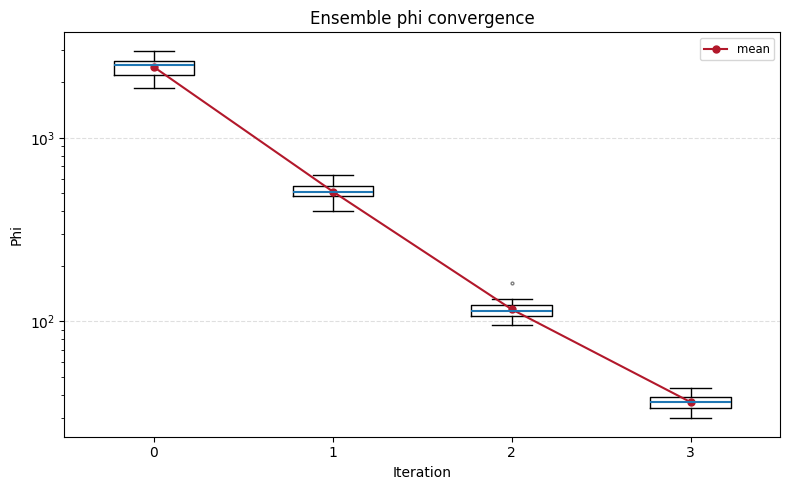

In [16]:
import matplotlib.pyplot as plt

from iwfm_io.plots.calibration import (
    plot_ensemble_hydrograph, plot_obs_vs_sim, plot_parameter_histograms,
    plot_phi_by_group, plot_phi_convergence, plot_residual_butterfly)

fig, ax = plot_phi_convergence(r)
plt.show()

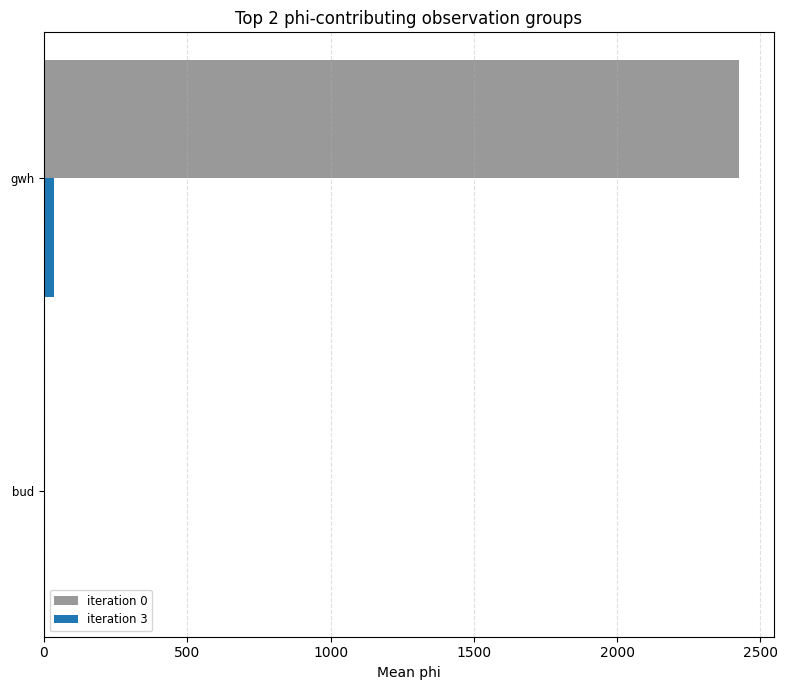

In [17]:
fig, ax = plot_phi_by_group(r)
plt.show()

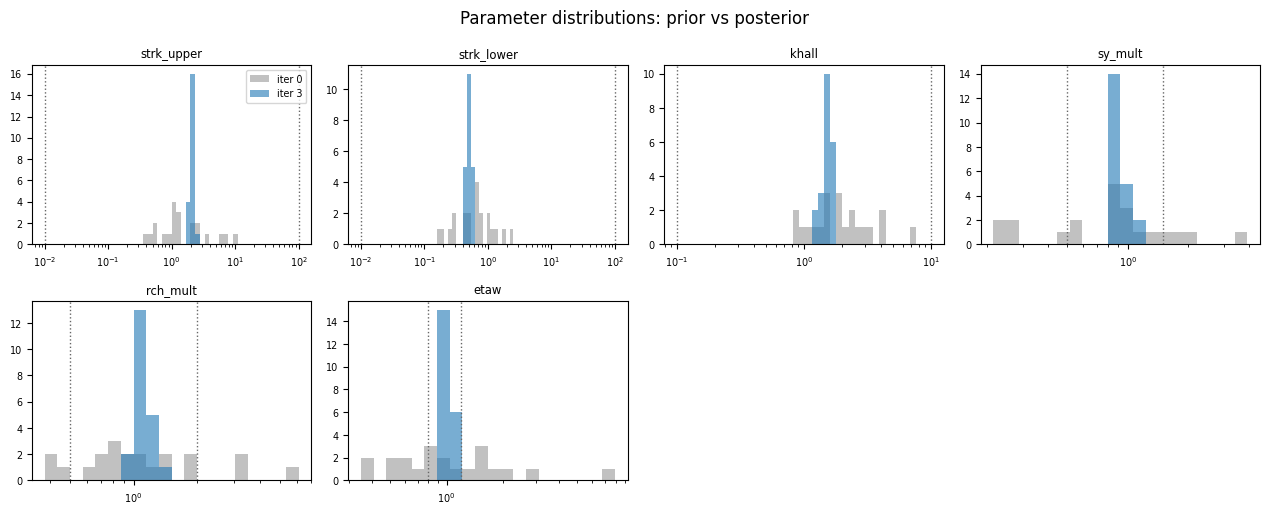

In [18]:
fig, axes = plot_parameter_histograms(r, par_data=par_data)
plt.show()

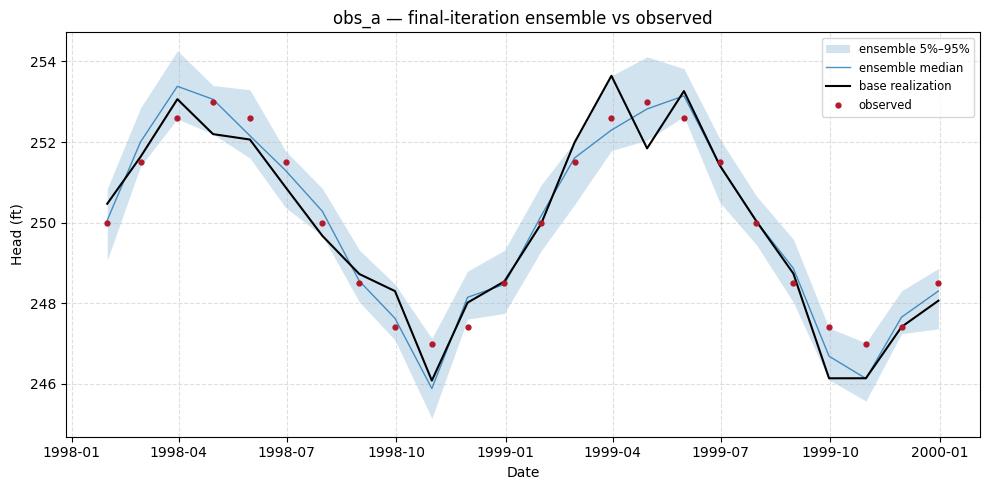

In [19]:
# ensemble hydrograph at one well: columns = realizations, rows = dates
well_cols = [n for n in obs_names if "_obs_a_" in n]
ens = r.obs(3)[well_cols].T
ens.index = dates
obs_series = pd.Series([truth[n] for n in well_cols], index=dates)

fig, ax = plot_ensemble_hydrograph(
    ens, observed=obs_series, ylabel="Head (ft)",
    title="obs_a — final-iteration ensemble vs observed")
plt.show()

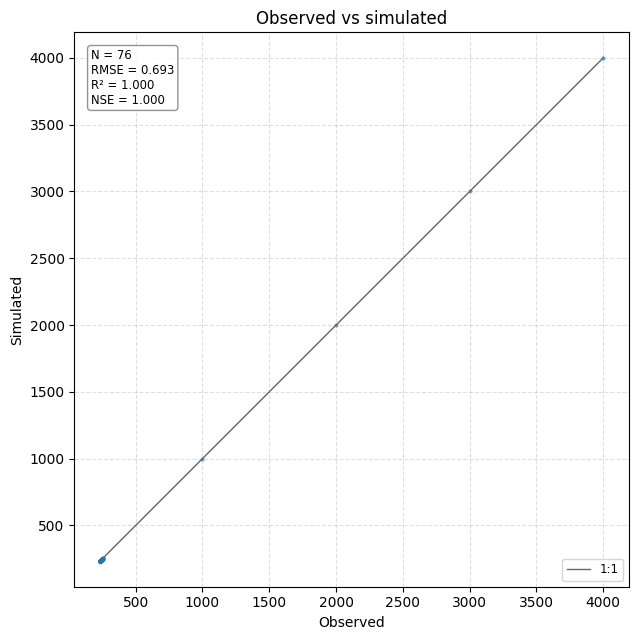

In [20]:
fig, ax = plot_obs_vs_sim(rei, observed="measured", simulated="modelled")
plt.show()

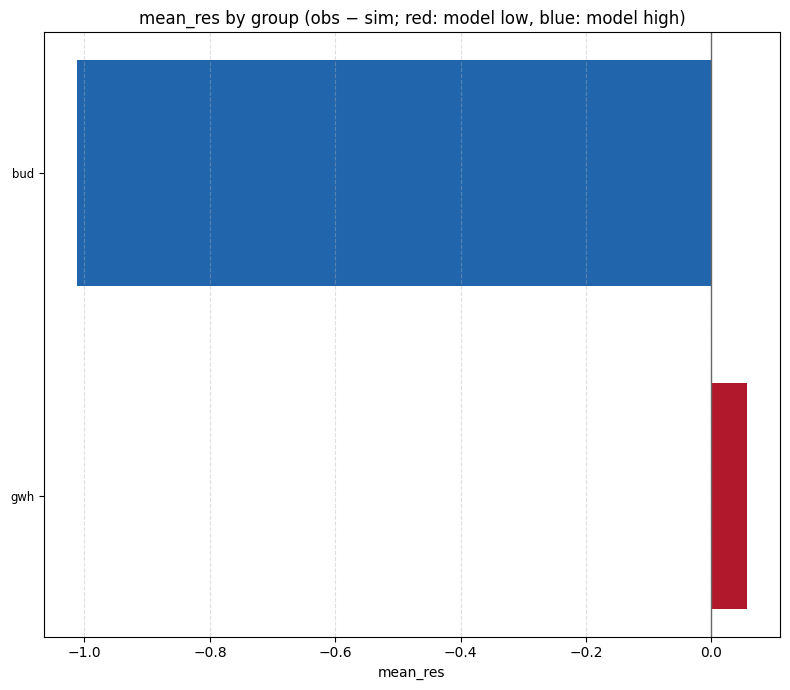

In [21]:
fig, ax = plot_residual_butterfly(rei_stats(rei, by="group"))
plt.show()

## Derived observations

Heads alone under-constrain a model. The DWR-proven trick is calibrating
on *derived* quantities — applied **identically** to observed and
simulated series, so systematic bias cancels:

- `head_changes` — successive / seasonal (Mar-over-Mar) / spring–fall
  drawdown
- `vertical_head_difference` — shallow-minus-deep pairs (gradients)
- `accretion_depletion` — downstream-minus-upstream gauge pairs
- `long_term_stats` — per-site means as soft targets

In [22]:
from iwfm_io.pest import head_changes

heads_long = pd.DataFrame({
    "site": "obs_a", "datetime": dates,
    "value": [truth[n] for n in well_cols]})

head_changes(heads_long, "successive").head(3)

,site,datetime,value
0,obs_a,1998-02-28,1.500000
1,obs_a,1998-03-31,1.098076
2,obs_a,1998-04-30,0.401924


In [23]:
head_changes(heads_long, "drawdown", from_month=3, to_month=9,
             obs_type="ddn")

,obsnme,site,datetime,value
0,ddn_obs_a_19980930,obs_a,1998-09-30,5.196152
1,ddn_obs_a_19990930,obs_a,1999-09-30,5.196152


In [24]:
from iwfm_io.pest import vertical_head_difference

two = pd.concat([
    heads_long,
    heads_long.assign(site="obs_a_deep", value=heads_long["value"] - 12.0),
])
vertical_head_difference(two, {"pair_a": ("obs_a", "obs_a_deep")},
                         obs_type="vhd").head(3)

,obsnme,site,datetime,value
0,vhd_pair_a_19980131,pair_a,1998-01-31,12.0
1,vhd_pair_a_19980228,pair_a,1998-02-28,12.0
2,vhd_pair_a_19980331,pair_a,1998-03-31,12.0


In [25]:
# constant bias cancels: biased sim, identical derived residuals
from iwfm_io.pest import residual_stats

sim_biased = heads_long.assign(value=heads_long["value"] + 5.0)
d_obs = head_changes(heads_long, "successive")
d_sim = head_changes(sim_biased, "successive")
paired = d_obs.merge(d_sim, on=["site", "datetime"], suffixes=("_obs", "_sim"))
residual_stats(paired, observed="value_obs", simulated="value_sim")[
    ["n", "mean_res", "rmse"]]

,n,mean_res,rmse
group,,,
all,23,0.0,0.0


## After the analysis: finals reruns

Two orchestration helpers close the loop (shown in notebook 09's
template layout):

```python
from iwfm_io.pest import parrep_v2, run_finals

# stage the best realization's parameters into a template copy and
# set noptmax=0 for a single verification run
run_finals(r, template_dir, final_dir, realization=r.best_realization())

# or surgically: write any parameter Series into a v2 control file
parrep_v2(final_dir / "case.pst", r.par().loc["base"])
```

In [26]:
import shutil

shutil.rmtree(WORK, ignore_errors=True)
print("workspace removed")

workspace removed


## Recap

```
load_ies_ensembles(master)  ->  describe() first, always
  .phi_summary() / .best_realization()   convergence at a glance
  ies_stats(r, by=...)                   fit metrics per iter x real x group
  diagnose_ies(r, par_data=...)          the full audit, as signals
  plots.calibration.*                    the figure set
run_finals(...)                          rerun the winner
```

On a real run the only thing that changes is the path passed to
`load_ies_ensembles`. The pest module was validated against a
production CalSim3 + C2VSimCG IES calibration.